# ✋ Sign Language Recognition Using Deep Learning  
## Week 1 — Exploratory Data Analysis

---

## Introduction

This project focuses on building a deep learning model for recognizing American Sign Language hand gestures.

The main idea is simple: the model receives an image of a hand gesture and predicts which ASL letter or sign it represents.

This project is important because sign language recognition can be used as a digital assistant for accessibility and communication support.

In Week 1, I focus on understanding the dataset before building the model.

## Week 1 Goals

The main goals of this week are:

- download and extract the dataset;
- check dataset folder structure;
- identify all gesture classes;
- count images in each class;
- visualize sample images;
- inspect image size and color mode;
- analyze pixel values;
- prepare the project for preprocessing in Week 2.

In [5]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

## Dataset Download

The dataset was downloaded from Kaggle using the Kaggle API.

Dataset: **ASL Alphabet**  
Link: https://www.kaggle.com/datasets/grassknoted/asl-alphabet

The dataset archive is saved as:

```text
asl-alphabet.zip

In [1]:
# Install Kaggle library
!pip install -q kaggle

In [6]:

print(os.listdir())

['.config', 'kaggle.json', 'asl-alphabet.zip', 'sample_data']


In [2]:
# Upload kaggle.json file

from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darynminal","key":"6b38091e2cb8901c5eb56442ea926569"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:04<00:00, 226MB/s]



## Extracting Dataset

Now I extract the downloaded ZIP file.

In [7]:
if os.path.exists("asl-alphabet.zip"):
    with zipfile.ZipFile("asl-alphabet.zip", "r") as zip_ref:
        zip_ref.extractall("data")

    print("Dataset extracted successfully into data/ folder.")
else:
    print("asl-alphabet.zip not found. Please download the dataset first.")

Dataset extracted successfully into data/ folder.


## Checking Extracted Files

After extraction, I check the folder structure.

In [8]:
os.listdir("data")

['asl_alphabet_train', 'asl_alphabet_test']

## Finding Training Dataset Folder

The ASL Alphabet dataset contains folders for different gesture classes.

I search for the folder that contains many class folders such as A, B, C, etc.

In [9]:
dataset_path = None

for root, dirs, files in os.walk("data"):
    if len(dirs) >= 20:
        dataset_path = root
        break

print("Dataset path:", dataset_path)

Dataset path: data/asl_alphabet_train/asl_alphabet_train


## Class Names

Each folder represents one class.

Examples:

- A
- B
- C
- space
- del
- nothing

In [10]:
class_names = sorted([
    class_name for class_name in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, class_name))
])

print("Number of classes:", len(class_names))
print("Class names:")
print(class_names)

Number of classes: 29
Class names:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Class Distribution

Now I count how many images are inside each class folder.

This is important because class imbalance can affect model training.

In [11]:
class_counts = {}

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(image_files)

class_counts

{'A': 3000,
 'B': 3000,
 'C': 3000,
 'D': 3000,
 'E': 3000,
 'F': 3000,
 'G': 3000,
 'H': 3000,
 'I': 3000,
 'J': 3000,
 'K': 3000,
 'L': 3000,
 'M': 3000,
 'N': 3000,
 'O': 3000,
 'P': 3000,
 'Q': 3000,
 'R': 3000,
 'S': 3000,
 'T': 3000,
 'U': 3000,
 'V': 3000,
 'W': 3000,
 'X': 3000,
 'Y': 3000,
 'Z': 3000,
 'del': 3000,
 'nothing': 3000,
 'space': 3000}

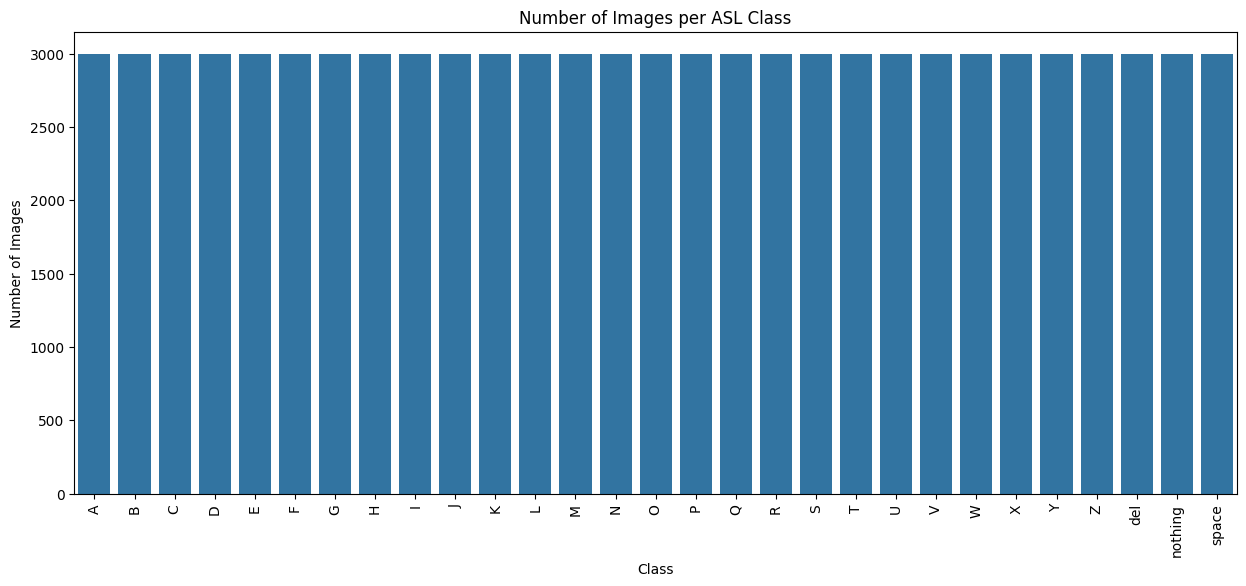

In [12]:
plt.figure(figsize=(15, 6))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Number of Images per ASL Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)

plt.show()

### Observation

The dataset contains many images for each ASL class.

This is good for CNN training because the model needs enough examples to learn visual differences between gestures.

If the classes are relatively balanced, the model can learn more fairly.

## Visualizing Sample Images

Now I display sample images from different ASL classes.

This helps me understand what the model will learn visually.

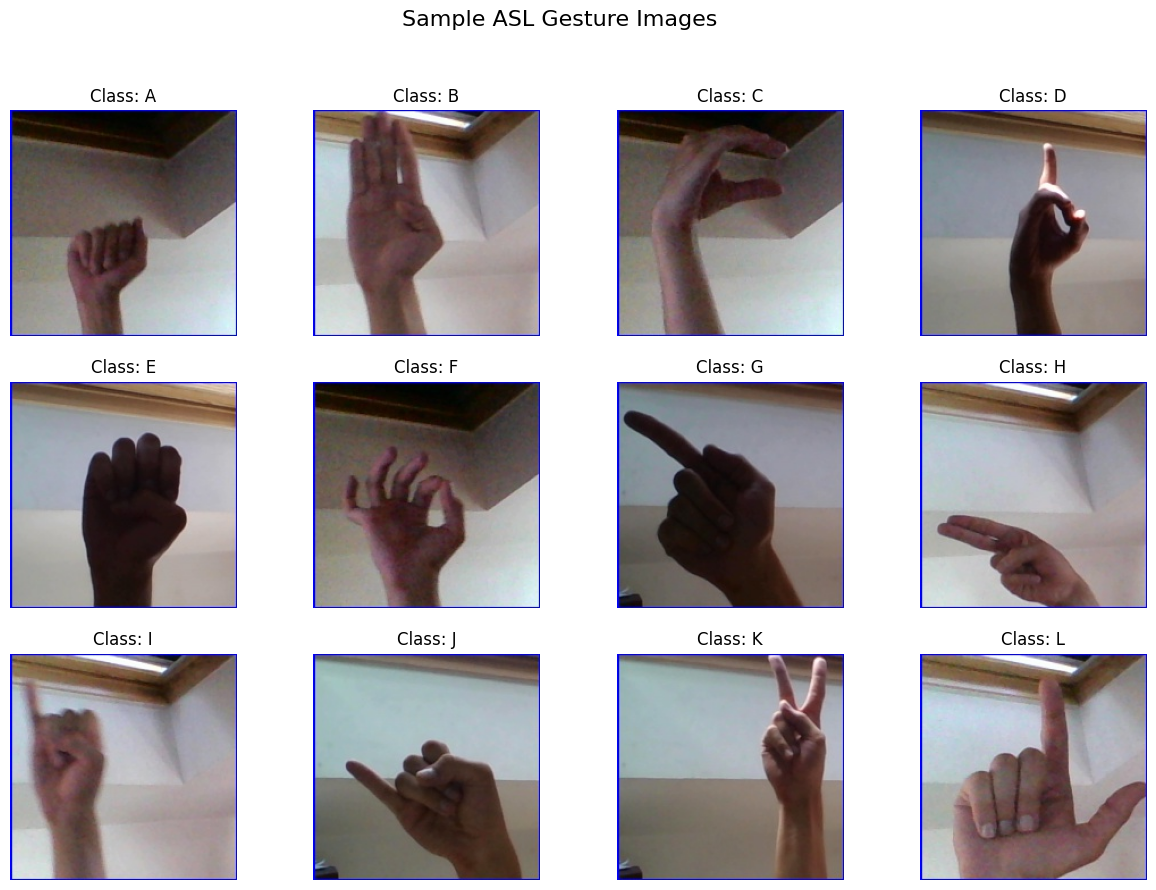

In [13]:
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names[:12]):
    class_folder = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_folder, image_files[0])
    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {class_name}")
    plt.axis("off")

plt.suptitle("Sample ASL Gesture Images", fontsize=16)
plt.show()

### Observation

The images show different hand gestures representing ASL letters and special signs.

The visual differences include:

- finger positions;
- hand shape;
- palm direction;
- gesture structure.

These patterns are exactly what a CNN model can learn.

## Checking Image Properties

Before preprocessing, I check image size, color mode, and array shape.

In [14]:
sample_class = class_names[0]
sample_folder = os.path.join(dataset_path, sample_class)

sample_image_name = [
    file for file in os.listdir(sample_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

sample_image_path = os.path.join(sample_folder, sample_image_name)
sample_image = Image.open(sample_image_path)

print("Sample image path:", sample_image_path)
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Sample image path: data/asl_alphabet_train/asl_alphabet_train/A/A2380.jpg
Image size: (200, 200)
Image mode: RGB


In [15]:
sample_array = np.array(sample_image)

print("Image array shape:", sample_array.shape)

Image array shape: (200, 200, 3)


### Observation

The image is stored as an RGB image.

This means it has three color channels:

```text
Red, Green, Blue



```markdown
## Checking Image Sizes Across Classes

Now I check several images from different classes to see whether image sizes are consistent.

In [16]:
image_sizes = []

for class_name in class_names[:15]:
    class_folder = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(class_folder, image_files[0])
    image = Image.open(image_path)

    image_sizes.append(image.size)

image_sizes

[(200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200),
 (200, 200)]

### Observation

Even if most images have similar sizes, CNN models need a fixed input size.

Because of this, in Week 2 I will resize all images to a standard size such as:

```text
64 × 64

In [17]:
print("Minimum pixel value:", sample_array.min())
print("Maximum pixel value:", sample_array.max())
print("Mean pixel value:", sample_array.mean())
print("Standard deviation:", sample_array.std())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 101.58841666666666
Standard deviation: 63.72046256234902


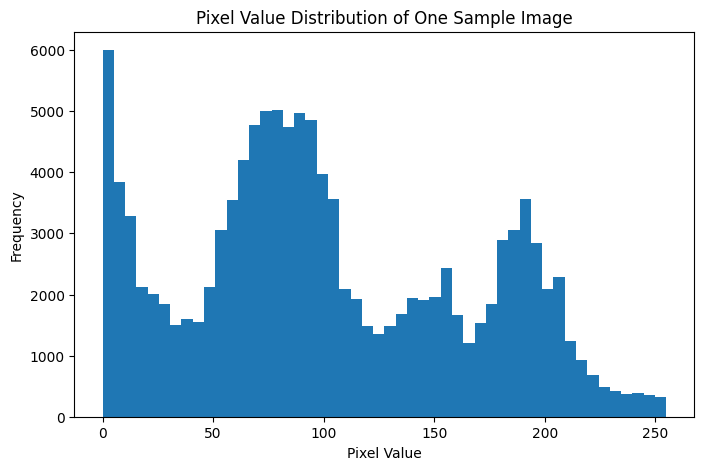

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(sample_array.flatten(), bins=50)

plt.title("Pixel Value Distribution of One Sample Image")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

### Observation

The pixel values are in the range from 0 to 255.

For neural network training, these values should be normalized to the range:

```text
0 to 1

## Key Findings

During Week 1, I found that:

- the dataset contains many ASL gesture classes;
- each class is stored in a separate folder;
- the dataset is suitable for CNN image classification;
- the images are RGB;
- images need resizing before training;
- pixel values need normalization;
- data augmentation will be useful for better generalization.

## Plan for Week 2

In Week 2, I will prepare the dataset for model training.

The main tasks will be:

- load images using image generators;
- resize all images;
- normalize pixel values;
- split data into training and validation sets;
- apply data augmentation;
- visualize augmented images;
- prepare the CNN input pipeline.

## Week 1 Conclusion

Week 1 was focused on understanding the ASL Alphabet dataset.

I explored the dataset structure, checked class folders, counted images, visualized sample gestures, and analyzed image properties.

This dataset is a strong choice for a deep learning project because it is visual, practical, and socially meaningful.

The project is now ready for Week 2: preprocessing and data augmentation.